# 03 -- Modele OLS
## RobynMMM -- Business Scientist MCE -- Ekimetrics

**Objectif :** estimer la contribution de chaque canal media aux ventes via une regression lineaire (OLS) avec `statsmodels`. Produire les livrables consultant : decomposition des ventes, ROAS par canal, diagnostics econometriques.

---
### Plan
1. Chargement des features transformees
2. Construction du modele OLS
3. Lecture et interpretation des resultats
4. Diagnostics econometriques
5. Decomposition des ventes (waterfall)
6. ROAS par canal
7. Synthese consultant

## 0. Imports & chargement

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson
from scipy import stats
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.dpi": 120, "figure.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.3, "font.size": 11,
})

# Chargement du dataset features (output notebook 02)
FEAT_PATH = Path("../data/processed/dt_features.parquet")
df = pd.read_parquet(FEAT_PATH)
df["date"] = pd.to_datetime(df["date"])

MEDIA_COLS = ["tv_S", "ooh_S", "print_S", "facebook_S", "search_S"]
MEDIA_LABELS = {"tv_S":"TV","ooh_S":"OOH","print_S":"Print","facebook_S":"Facebook","search_S":"Search"}
MEDIA_COLORS = {"tv_S":"#4E9AF1","ooh_S":"#F5C842","print_S":"#6BCB77","facebook_S":"#FF7043","search_S":"#9C5CF5"}
media_present = [c for c in MEDIA_COLS if c in df.columns]
trans_cols = [f"{c}_transformed" for c in media_present if f"{c}_transformed" in df.columns]

Path("../outputs/figures").mkdir(parents=True, exist_ok=True)
Path("../outputs/models").mkdir(parents=True, exist_ok=True)

print(f"[OK] Dataset charge : {df.shape}")
print(f"\nFeatures disponibles :")
print(f"  Media transformees : {trans_cols}")
print(f"  Colonnes controle  : {[c for c in df.columns if c in ['events','newsletter','competitor_sales_B','trend','month']]}")
print(f"\nApercu revenue : mean={df['revenue'].mean()/1e6:.2f}M  std={df['revenue'].std()/1e6:.2f}M")

[OK] Dataset charge : (208, 20)

Features disponibles :
  Media transformees : ['tv_S_transformed', 'ooh_S_transformed', 'print_S_transformed', 'facebook_S_transformed', 'search_S_transformed']
  Colonnes controle  : ['trend', 'month']

Apercu revenue : mean=1.82M  std=0.72M


## 1. Construction du modele OLS

### Specification

Le modele estime :

```
revenue(t) = alpha
           + beta_TV      * sat(adstock(TV))
           + beta_OOH     * sat(adstock(OOH))
           + beta_Print   * sat(adstock(Print))
           + beta_Facebook* sat(adstock(Facebook))
           + beta_Search  * sat(adstock(Search))
           + gamma_trend  * t
           + gamma_month  * month_dummies
           + gamma_events * events
           + epsilon(t)
```

Chaque **beta** mesure combien une unite d'effet media (0 a 1) genere de revenue.

In [3]:
# Variables explicatives
X_media = df[trans_cols].copy()

# Variables de controle
control_cols = []
if "trend" in df.columns:
    control_cols.append("trend")
if "events" in df.columns:
    control_cols.append("events")
if "newsletter" in df.columns:
    control_cols.append("newsletter")

# Saisonnalite : dummies mois (reference = janvier)
month_dummies = pd.get_dummies(df["month"], prefix="m", drop_first=True)
month_dummies = month_dummies.astype(float)

# Assembler X
X = pd.concat([X_media, df[control_cols], month_dummies], axis=1)
X = sm.add_constant(X)  # intercept
y = df["revenue"]

print(f"Variables explicatives ({X.shape[1]}) :")
print(f"  Media    : {trans_cols}")
print(f"  Controles: {control_cols}")
print(f"  Saison   : {list(month_dummies.columns)[:3]} ... ({len(month_dummies.columns)} dummies)")
print(f"\nShape X : {X.shape}  |  Shape y : {y.shape}")

Variables explicatives (18) :
  Media    : ['tv_S_transformed', 'ooh_S_transformed', 'print_S_transformed', 'facebook_S_transformed', 'search_S_transformed']
  Controles: ['trend']
  Saison   : ['m_2', 'm_3', 'm_4'] ... (11 dummies)

Shape X : (208, 18)  |  Shape y : (208,)


In [6]:
# Estimation OLS
model = sm.OLS(y, X.astype(float))
results = model.fit()

print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                revenue   R-squared:                       0.835
Model:                            OLS   Adj. R-squared:                  0.820
Method:                 Least Squares   F-statistic:                     56.37
Date:                Sat, 18 Apr 2026   Prob (F-statistic):           1.06e-64
Time:                        13:57:34   Log-Likelihood:                -2911.8
No. Observations:                 208   AIC:                             5860.
Df Residuals:                     190   BIC:                             5920.
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                   1.48

## 2. Interpretation des resultats

### Guide de lecture

| Statistique | Ce que ca mesure | Seuil acceptable |
|---|---|---|
| **R²** | % de variance expliquee | > 0.7 en MMM |
| **R² ajuste** | R² penalise par nb variables | proche du R² |
| **F-statistic** | Significativite globale | p < 0.05 |
| **p-value coef** | Significativite du canal | < 0.05 (voire 0.10) |
| **coef** | Effet unitaire du canal | > 0 attendu |
| **IC 95%** | Plage de confiance | Doit exclure 0 |

In [7]:
# Extraction des resultats cles
print("=" * 65)
print("  RESULTATS OLS -- INDICATEURS GLOBAUX")
print("=" * 65)
print(f"  R²              : {results.rsquared:.4f}")
print(f"  R² ajuste       : {results.rsquared_adj:.4f}")
print(f"  F-statistic     : {results.fvalue:.2f}  (p={results.f_pvalue:.2e})")
print(f"  AIC             : {results.aic:.1f}")
print(f"  BIC             : {results.bic:.1f}")
print(f"  Nb observations : {int(results.nobs)}")
print(f"  Nb parametres   : {len(results.params)}")

print()
print("=" * 65)
print("  COEFFICIENTS DES CANAUX MEDIA")
print("=" * 65)
print(f"  {'Canal':<16} {'Coef':>12} {'p-value':>10} {'IC 95% lo':>12} {'IC 95% hi':>12} {'Sig'}")
print("  " + "-" * 64)

for col, label in zip(trans_cols, [MEDIA_LABELS[c] for c in media_present]):
    if col in results.params.index:
        coef = results.params[col]
        pval = results.pvalues[col]
        ci_lo = results.conf_int().loc[col, 0]
        ci_hi = results.conf_int().loc[col, 1]
        sig = "***" if pval < 0.001 else "**" if pval < 0.01 else "*" if pval < 0.05 else "." if pval < 0.10 else "ns"
        print(f"  {label:<16} {coef:>12,.0f} {pval:>10.4f} {ci_lo:>12,.0f} {ci_hi:>12,.0f}  {sig}")

print()
print("  Significativite : *** p<0.001  ** p<0.01  * p<0.05  . p<0.10  ns non-sig")

  RESULTATS OLS -- INDICATEURS GLOBAUX
  R²              : 0.8345
  R² ajuste       : 0.8197
  F-statistic     : 56.37  (p=1.06e-64)
  AIC             : 5859.5
  BIC             : 5919.6
  Nb observations : 208
  Nb parametres   : 18

  COEFFICIENTS DES CANAUX MEDIA
  Canal                    Coef    p-value    IC 95% lo    IC 95% hi Sig
  ----------------------------------------------------------------
  TV                    497,611     0.0000      289,801      705,421  ***
  OOH                    64,451     0.4589     -106,838      235,740  ns
  Print                 138,902     0.1837      -66,441      344,244  ns
  Facebook              269,632     0.0020       99,906      439,357  **
  Search                571,297     0.0007      242,804      899,791  ***

  Significativite : *** p<0.001  ** p<0.01  * p<0.05  . p<0.10  ns non-sig


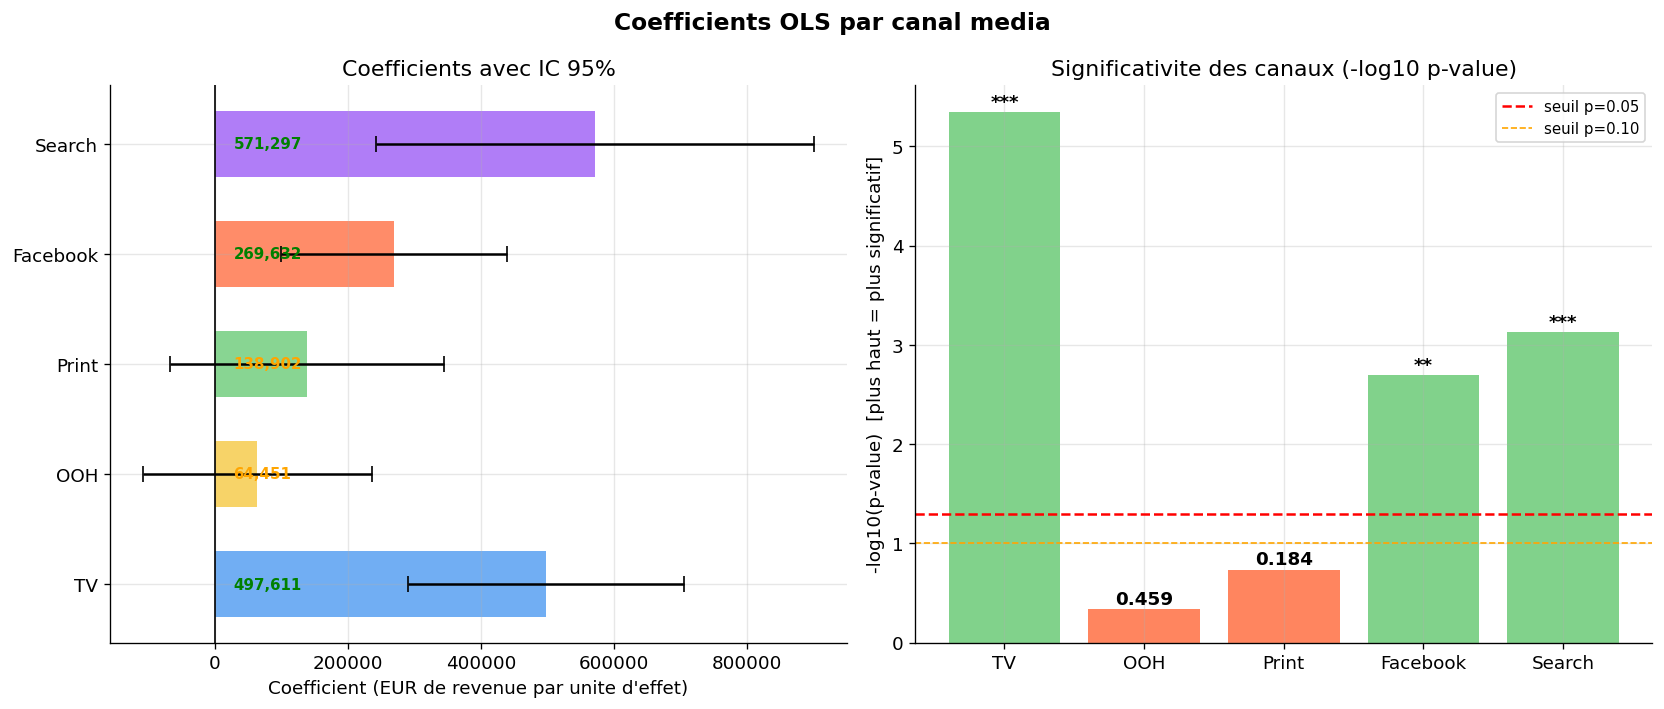

[OK] Figure sauvegardee


In [8]:
# Visualisation des coefficients avec IC
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Coefficients OLS par canal media", fontsize=14, fontweight="bold")

# Coefs avec IC 95%
ax = axes[0]
coefs = []
ci_lo = []
ci_hi = []
labels_plot = []
colors_plot = []

for col, mc in zip(trans_cols, media_present):
    if col in results.params.index:
        coefs.append(results.params[col])
        ci_lo.append(results.conf_int().loc[col, 0])
        ci_hi.append(results.conf_int().loc[col, 1])
        labels_plot.append(MEDIA_LABELS[mc])
        colors_plot.append(MEDIA_COLORS[mc])

y_pos = range(len(coefs))
ax.barh(y_pos, coefs, color=colors_plot, alpha=0.8, height=0.6)
ax.errorbar(coefs, y_pos,
            xerr=[np.array(coefs) - np.array(ci_lo), np.array(ci_hi) - np.array(coefs)],
            fmt="none", color="black", capsize=5, linewidth=1.5)
ax.axvline(x=0, color="black", linewidth=1)
ax.set_yticks(list(y_pos))
ax.set_yticklabels(labels_plot)
ax.set_xlabel("Coefficient (EUR de revenue par unite d'effet)")
ax.set_title("Coefficients avec IC 95%")

for i, (c, lo, hi) in enumerate(zip(coefs, ci_lo, ci_hi)):
    color_text = "green" if lo > 0 else "red" if hi < 0 else "orange"
    ax.text(max(coefs)*0.05, i, f"{c:,.0f}", va="center", fontsize=9,
            color=color_text, fontweight="bold")

# p-values
ax2 = axes[1]
pvals = [results.pvalues[col] for col in trans_cols if col in results.pvalues.index]
colors_pval = ["#6BCB77" if p < 0.05 else "#F5C842" if p < 0.10 else "#FF7043" for p in pvals]
bars = ax2.bar(labels_plot, [-np.log10(p) for p in pvals], color=colors_pval, alpha=0.85)
ax2.axhline(y=-np.log10(0.05), color="red", linestyle="--", linewidth=1.5, label="seuil p=0.05")
ax2.axhline(y=-np.log10(0.10), color="orange", linestyle="--", linewidth=1, label="seuil p=0.10")
ax2.set_ylabel("-log10(p-value)  [plus haut = plus significatif]")
ax2.set_title("Significativite des canaux (-log10 p-value)")
ax2.legend(fontsize=9)

for bar, pv in zip(bars, pvals):
    sig = "***" if pv < 0.001 else "**" if pv < 0.01 else "*" if pv < 0.05 else f"{pv:.3f}"
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             sig, ha="center", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.savefig("../outputs/figures/03_coefficients.png", bbox_inches="tight", dpi=150)
plt.show()
print("[OK] Figure sauvegardee")

## 3. Diagnostics econometriques

### Pourquoi les diagnostics sont essentiels

Un bon R² ne suffit pas. Les hypotheses de la regression OLS doivent etre verifiees :

| Hypothese | Test | Probleme si viole |
|---|---|---|
| **Normalite des residus** | QQ-plot, Jarque-Bera | IC et p-values biaises |
| **Homoscedasticite** | Residus vs fitted | Erreurs std sous-estimees |
| **Absence d'autocorrelation** | Durbin-Watson | Efficacite perdue |
| **Absence de multicollinearite** | VIF | Coefficients instables |

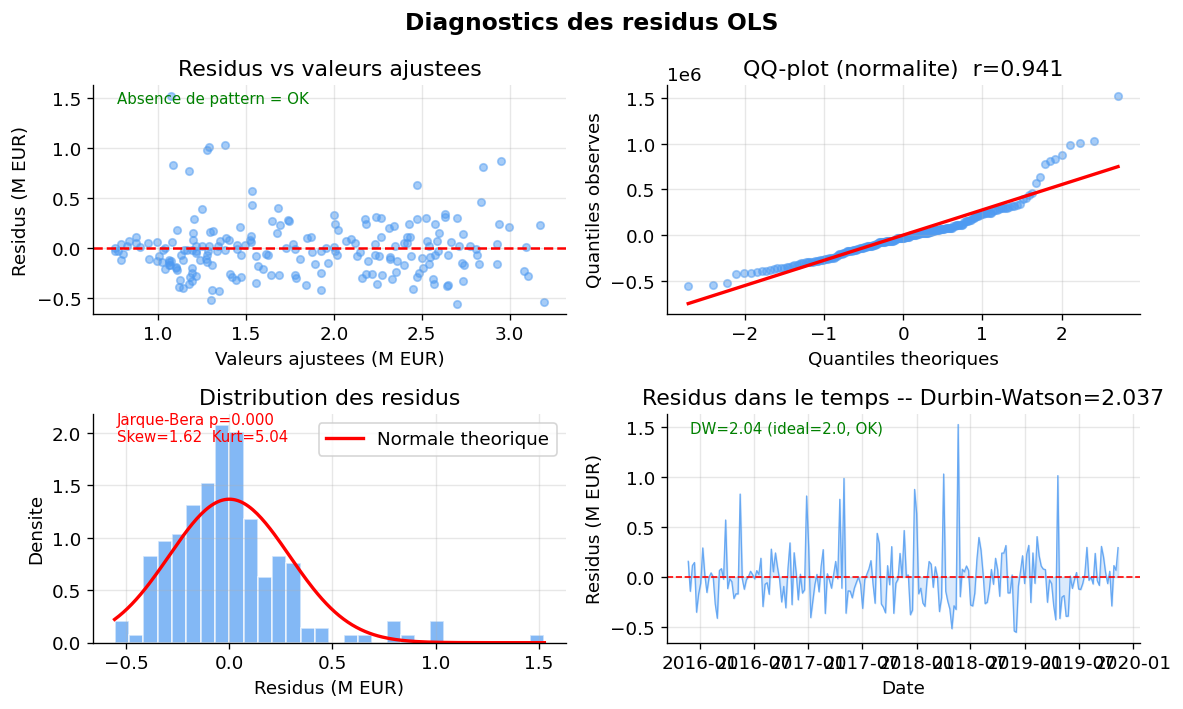

[OK] Figure sauvegardee


In [14]:
fig, axes = plt.subplots(2, 2, figsize=(10, 6))
fig.suptitle("Diagnostics des residus OLS", fontsize=14, fontweight="bold")

residuals = results.resid
fitted    = results.fittedvalues
std_resid = residuals / residuals.std()

# 1. Residus vs valeurs ajustees (homoscedasticite)
ax = axes[0, 0]
ax.scatter(fitted/1e6, residuals/1e6, alpha=0.5, s=20, color="#4E9AF1")
ax.axhline(y=0, color="red", linewidth=1.5, linestyle="--")
ax.set_xlabel("Valeurs ajustees (M EUR)")
ax.set_ylabel("Residus (M EUR)")
ax.set_title("Residus vs valeurs ajustees")
ax.annotate("Absence de pattern = OK", xy=(0.05, 0.92),
            xycoords="axes fraction", fontsize=9, color="green")

# 2. QQ-plot (normalite)
ax2 = axes[0, 1]
(osm, osr), (slope, intercept, r) = stats.probplot(residuals, dist="norm")
ax2.scatter(osm, osr, alpha=0.5, s=20, color="#4E9AF1")
ax2.plot(osm, slope*np.array(osm)+intercept, color="red", linewidth=2)
ax2.set_xlabel("Quantiles theoriques")
ax2.set_ylabel("Quantiles observes")
ax2.set_title(f"QQ-plot (normalite)  r={r:.3f}")

# 3. Distribution des residus
ax3 = axes[1, 0]
ax3.hist(residuals/1e6, bins=30, color="#4E9AF1", alpha=0.7,
         density=True, edgecolor="white")
x_norm = np.linspace(residuals.min()/1e6, residuals.max()/1e6, 200)
ax3.plot(x_norm,
         stats.norm.pdf(x_norm, residuals.mean()/1e6, residuals.std()/1e6),
         color="red", linewidth=2, label="Normale theorique")
ax3.set_xlabel("Residus (M EUR)")
ax3.set_ylabel("Densite")
ax3.set_title("Distribution des residus")
ax3.legend()

jb_result = stats.jarque_bera(residuals)
jb_stat, jb_pval = jb_result[0], jb_result[1]
skew = float(pd.Series(residuals).skew())
kurt = float(pd.Series(residuals).kurt())
jb_color = "green" if jb_pval > 0.05 else "red"
jb_txt = f"Jarque-Bera p={jb_pval:.3f}\nSkew={skew:.2f}  Kurt={kurt:.2f}"
ax3.annotate(jb_txt, xy=(0.05, 0.88), xycoords="axes fraction",
             fontsize=9, color=jb_color)

# 4. Residus dans le temps (autocorrelation)
ax4 = axes[1, 1]
ax4.plot(df["date"], residuals/1e6, color="#4E9AF1", linewidth=0.8, alpha=0.8)
ax4.axhline(y=0, color="red", linewidth=1, linestyle="--")
ax4.fill_between(df["date"], residuals/1e6, alpha=0.2, color="#4E9AF1")
ax4.set_xlabel("Date")
ax4.set_ylabel("Residus (M EUR)")
dw = durbin_watson(residuals)
dw_status = "OK" if 1.5 < dw < 2.5 else "autocorrelation detectee"
dw_color  = "green" if 1.5 < dw < 2.5 else "red"
ax4.set_title(f"Residus dans le temps -- Durbin-Watson={dw:.3f}")
ax4.annotate(f"DW={dw:.2f} (ideal=2.0, {dw_status})",
             xy=(0.05, 0.92), xycoords="axes fraction",
             fontsize=9, color=dw_color)

plt.tight_layout()
plt.savefig("../outputs/figures/03_diagnostics.png", bbox_inches="tight", dpi=150)
plt.show()
print("[OK] Figure sauvegardee")

=== VIF -- Multicollinearite ===
(VIF < 5 = OK | VIF 5-10 = attention | VIF > 10 = probleme)

              Variable       VIF
                 trend 10.850281
  search_S_transformed  9.204643
      tv_S_transformed  4.856319
   print_S_transformed  4.787823
     ooh_S_transformed  3.041072
facebook_S_transformed  2.557261



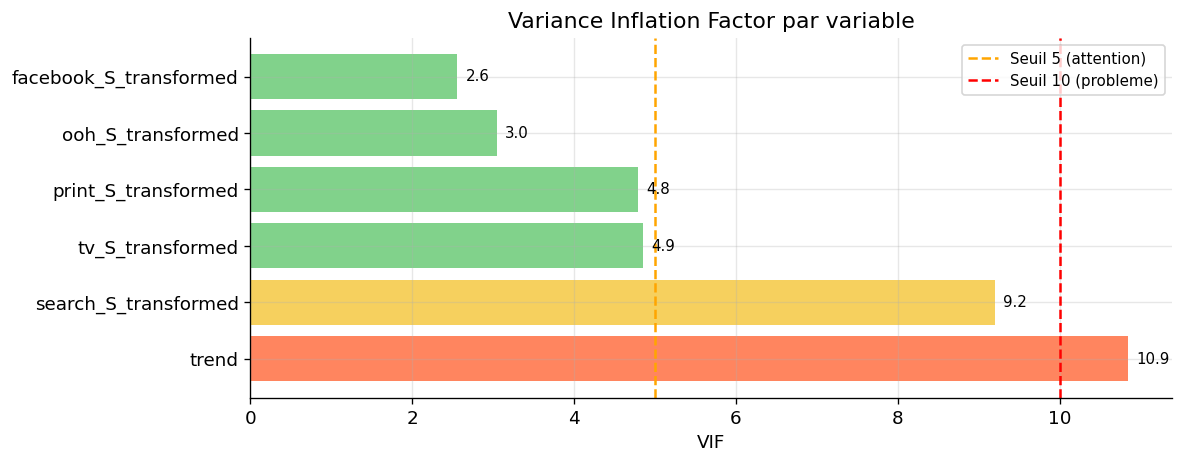

[OK] Figure sauvegardee


In [15]:
# VIF -- Variance Inflation Factor (multicollinearite)
print("=== VIF -- Multicollinearite ===")
print("(VIF < 5 = OK | VIF 5-10 = attention | VIF > 10 = probleme)")
print()

X_vif = X.drop(columns=["const"], errors="ignore").astype(float)
vif_data = pd.DataFrame({
    "Variable": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
}).sort_values("VIF", ascending=False)

# Afficher seulement les variables media et controles principaux
vif_media = vif_data[vif_data["Variable"].isin(trans_cols + ["trend","events","newsletter"])]
print(vif_media.to_string(index=False))

print()
# Visualisation
fig, ax = plt.subplots(figsize=(10, 4))
colors_vif = ["#FF7043" if v > 10 else "#F5C842" if v > 5 else "#6BCB77"
              for v in vif_media["VIF"]]
bars = ax.barh(vif_media["Variable"], vif_media["VIF"], color=colors_vif, alpha=0.85)
ax.axvline(x=5, color="orange", linestyle="--", linewidth=1.5, label="Seuil 5 (attention)")
ax.axvline(x=10, color="red", linestyle="--", linewidth=1.5, label="Seuil 10 (probleme)")
ax.set_xlabel("VIF")
ax.set_title("Variance Inflation Factor par variable")
ax.legend(fontsize=9)
for bar, val in zip(bars, vif_media["VIF"]):
    ax.text(val + 0.1, bar.get_y() + bar.get_height()/2,
            f"{val:.1f}", va="center", fontsize=9)
plt.tight_layout()
plt.savefig("../outputs/figures/03_vif.png", bbox_inches="tight", dpi=150)
plt.show()
print("[OK] Figure sauvegardee")

## 4. Decomposition des ventes

### Concept

Chaque vente peut etre decomposee en :
- **Baseline** : ventes organiques (intercept + tendance + saisonnalite)
- **Contribution media** : ventes generees par chaque canal

```
revenue(t) = baseline(t) + contrib_TV(t) + contrib_OOH(t) + ... + residus(t)
```

C'est le livrable numero 1 qu'Ekimetrics presente au client.

In [16]:
# Calcul des contributions
contributions = pd.DataFrame(index=df.index)
contributions["date"] = df["date"].values

# Contribution de chaque canal media
for col, mc in zip(trans_cols, media_present):
    if col in results.params.index:
        contributions[f"contrib_{mc}"] = results.params[col] * df[col].values

# Baseline = tout sauf les contributions media
media_contrib_total = sum(
    results.params[col] * df[col].values
    for col in trans_cols if col in results.params.index
)
contributions["baseline"] = results.fittedvalues.values - media_contrib_total
contributions["residus"]  = results.resid.values
contributions["revenue"]  = df["revenue"].values
contributions["fitted"]   = results.fittedvalues.values

print("=== Decomposition moyenne (EUR/semaine) ===")
total_rev = contributions["revenue"].mean()
print(f"Revenue moyen total  : {total_rev:>12,.0f} EUR")
print(f"Baseline             : {contributions['baseline'].mean():>12,.0f} EUR  ({contributions['baseline'].mean()/total_rev*100:.1f}%)")
for mc in media_present:
    col_c = f"contrib_{mc}"
    if col_c in contributions.columns:
        val = contributions[col_c].mean()
        pct = val / total_rev * 100
        print(f"{MEDIA_LABELS[mc]:<20} : {val:>12,.0f} EUR  ({pct:.1f}%)")
print(f"Residus              : {contributions['residus'].mean():>12,.0f} EUR")

contributions.head(3)

=== Decomposition moyenne (EUR/semaine) ===
Revenue moyen total  :    1,822,143 EUR
Baseline             :    1,279,521 EUR  (70.2%)
TV                   :      195,528 EUR  (10.7%)
OOH                  :       21,011 EUR  (1.2%)
Print                :       62,099 EUR  (3.4%)
Facebook             :       77,085 EUR  (4.2%)
Search               :      186,898 EUR  (10.3%)
Residus              :            0 EUR


,date,contrib_tv_S,contrib_ooh_S,contrib_print_S,contrib_facebook_S,contrib_search_S,baseline,residus,revenue,fitted
0,2015-11-23,118459.969941,0.000000,88316.876784,199691.017972,0.000000,2.192831e+06,155072.321511,2.754372e+06,2.599299e+06
1,2015-11-30,267608.885620,0.000000,67516.775618,105308.377004,96744.339905,2.191962e+06,-144863.631553,2.584277e+06,2.729140e+06
2,2015-12-07,163997.957893,43834.164933,50646.351881,163143.305881,113689.473534,1.899552e+06,112523.848519,2.547387e+06,2.434863e+06


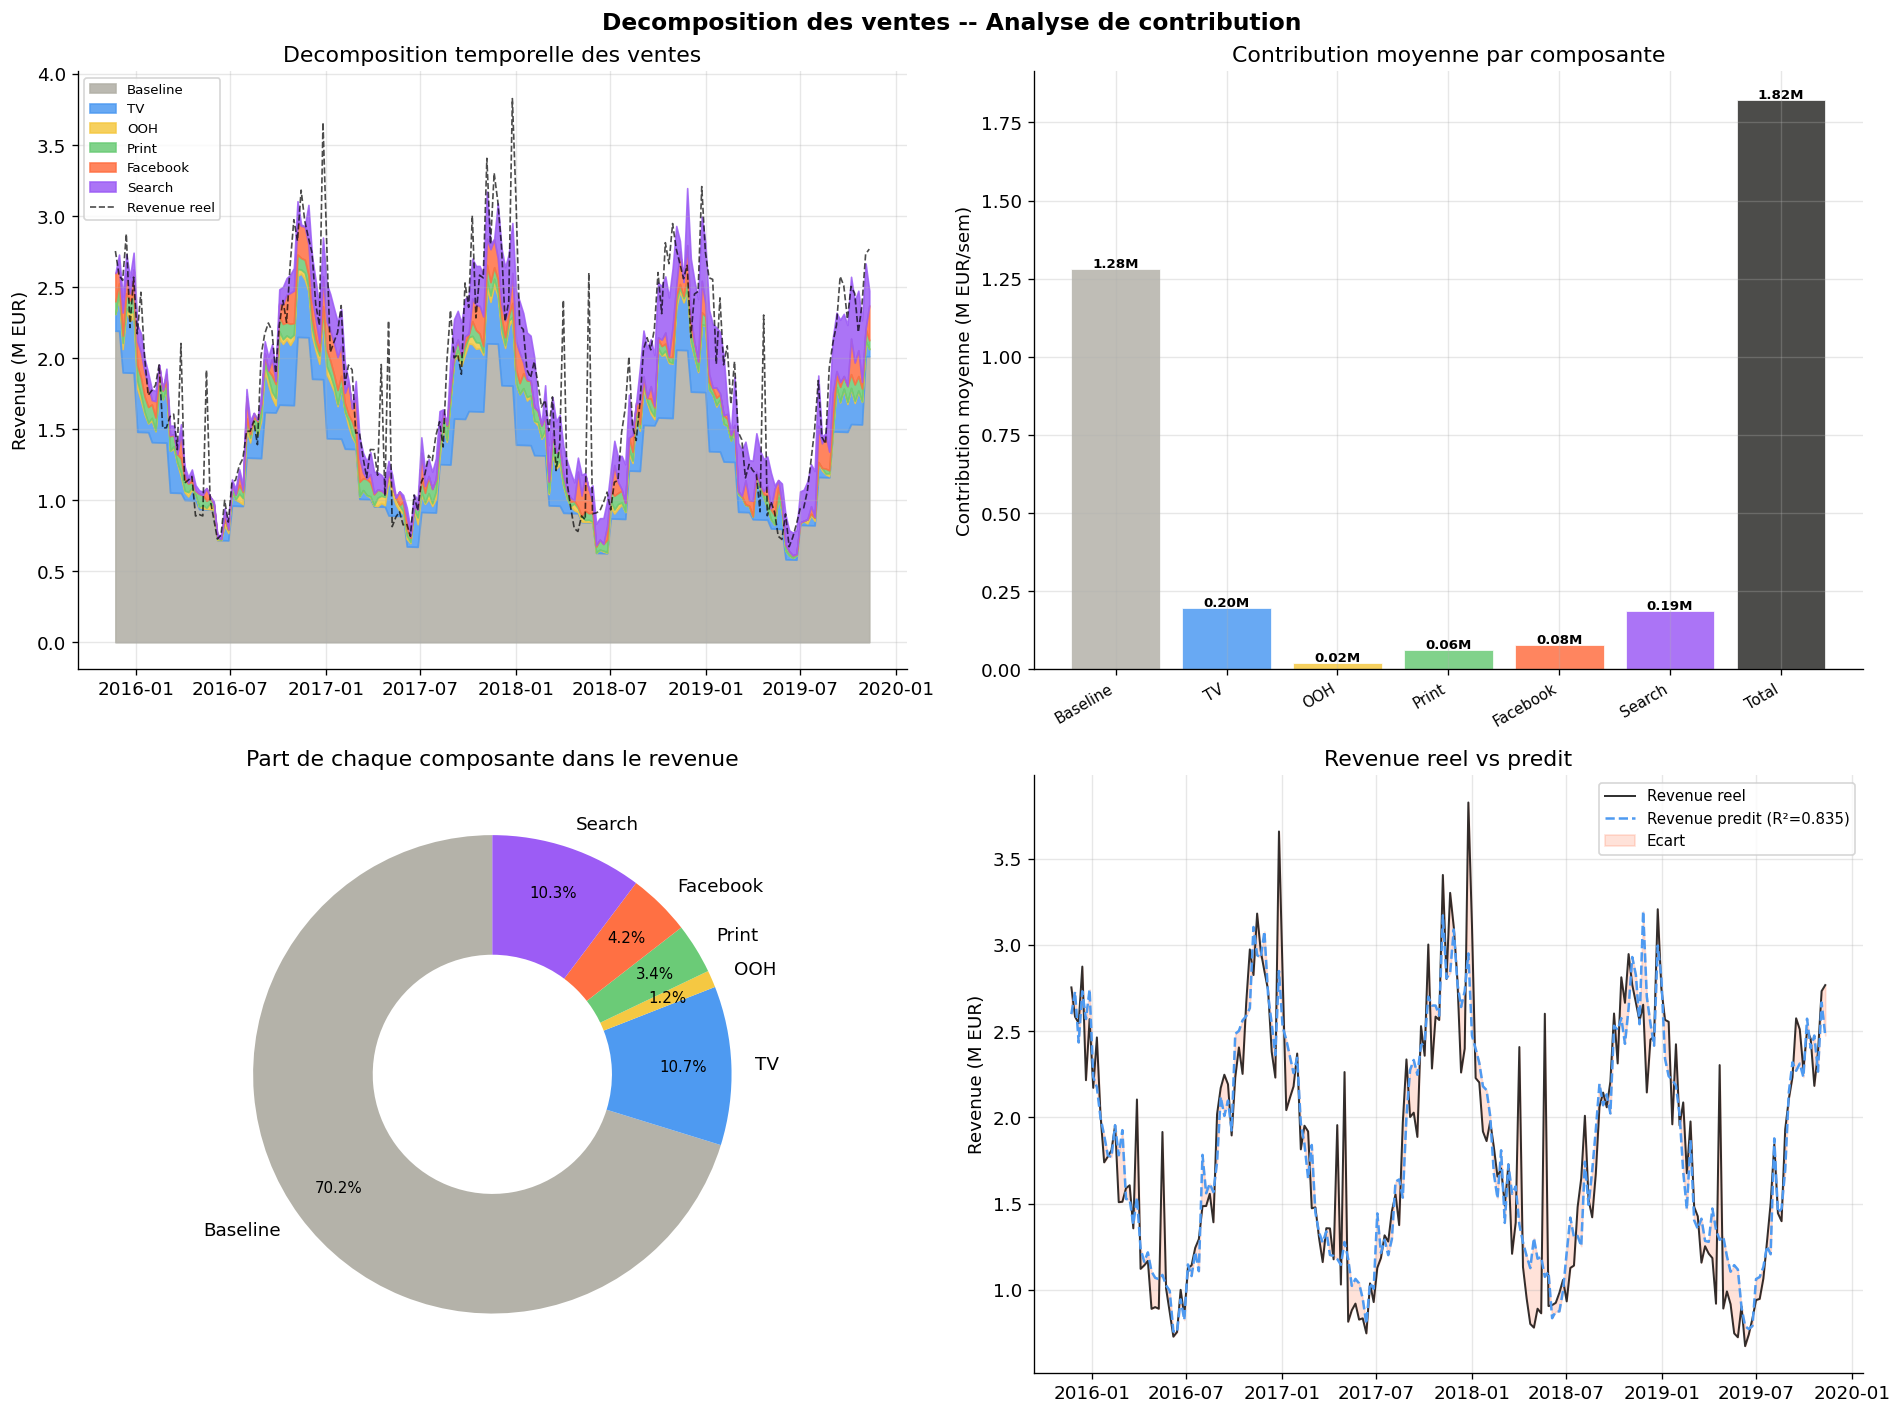

[OK] Figure sauvegardee


In [17]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Decomposition des ventes -- Analyse de contribution",
             fontsize=14, fontweight="bold")

# 1. Stacked area : decomposition temporelle
ax = axes[0, 0]
baseline_vals = contributions["baseline"].values / 1e6
bottom = baseline_vals.copy()
ax.fill_between(df["date"], 0, baseline_vals, alpha=0.9, color="#B4B2A9", label="Baseline")

for mc in media_present:
    col_c = f"contrib_{mc}"
    if col_c in contributions.columns:
        vals = contributions[col_c].values / 1e6
        ax.fill_between(df["date"], bottom, bottom + vals,
                       alpha=0.85, color=MEDIA_COLORS[mc], label=MEDIA_LABELS[mc])
        bottom += vals

ax.plot(df["date"], df["revenue"]/1e6, color="black", linewidth=1,
        linestyle="--", alpha=0.7, label="Revenue reel")
ax.set_title("Decomposition temporelle des ventes")
ax.set_ylabel("Revenue (M EUR)")
ax.legend(fontsize=8, loc="upper left")

# 2. Waterfall chart -- contributions moyennes
ax2 = axes[0, 1]
labels_wf = ["Baseline"] + [MEDIA_LABELS[mc] for mc in media_present] + ["Total"]
values_wf = [contributions["baseline"].mean()]
for mc in media_present:
    col_c = f"contrib_{mc}"
    values_wf.append(contributions[col_c].mean() if col_c in contributions.columns else 0)
values_wf.append(sum(values_wf))

colors_wf = ["#B4B2A9"] + [MEDIA_COLORS[mc] for mc in media_present] + ["#2C2C2A"]
bars = ax2.bar(range(len(labels_wf)), [v/1e6 for v in values_wf],
               color=colors_wf, alpha=0.85, edgecolor="white", linewidth=0.5)
ax2.set_xticks(range(len(labels_wf)))
ax2.set_xticklabels(labels_wf, rotation=30, ha="right", fontsize=9)
ax2.set_ylabel("Contribution moyenne (M EUR/sem)")
ax2.set_title("Contribution moyenne par composante")
for bar, val in zip(bars, values_wf):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f"{val/1e6:.2f}M", ha="center", fontsize=8, fontweight="bold")

# 3. Pie -- part des contributions
ax3 = axes[1, 0]
pie_labels = ["Baseline"] + [MEDIA_LABELS[mc] for mc in media_present]
pie_values = [max(contributions["baseline"].mean(), 0)]
for mc in media_present:
    col_c = f"contrib_{mc}"
    pie_values.append(max(contributions[col_c].mean() if col_c in contributions.columns else 0, 0))
pie_colors = ["#B4B2A9"] + [MEDIA_COLORS[mc] for mc in media_present]

wedges, texts, autotexts = ax3.pie(
    pie_values, labels=pie_labels, colors=pie_colors,
    autopct="%1.1f%%", pctdistance=0.8, startangle=90,
    wedgeprops={"width": 0.5})
for at in autotexts: at.set_fontsize(9)
ax3.set_title("Part de chaque composante dans le revenue")

# 4. Revenue reel vs predit
ax4 = axes[1, 1]
ax4.plot(df["date"], df["revenue"]/1e6, color="black", linewidth=1.2,
         label="Revenue reel", alpha=0.8)
ax4.plot(df["date"], results.fittedvalues/1e6, color="#4E9AF1", linewidth=1.5,
         linestyle="--", label=f"Revenue predit (R²={results.rsquared:.3f})")
ax4.fill_between(df["date"],
                 df["revenue"]/1e6, results.fittedvalues/1e6,
                 alpha=0.2, color="#FF7043", label="Ecart")
ax4.set_title("Revenue reel vs predit")
ax4.set_ylabel("Revenue (M EUR)")
ax4.legend(fontsize=9)

plt.tight_layout()
plt.savefig("../outputs/figures/03_decomposition.png", bbox_inches="tight", dpi=150)
plt.show()
print("[OK] Figure sauvegardee")

## 5. ROAS par canal

### Definition

```
ROAS = Revenue genere par le canal / Depenses du canal
     = contribution_canal.sum() / spend_canal.sum()
```

C'est l'indicateur cle qu'un client demande en premier : **combien chaque euro investi rapporte**.

In [18]:
roas_data = []
for mc in media_present:
    col_c = f"contrib_{mc}"
    if col_c not in contributions.columns:
        continue
    spend_total   = df[mc].sum()
    contrib_total = contributions[col_c].sum()
    roas          = contrib_total / spend_total if spend_total > 0 else 0
    spend_share   = spend_total / df[media_present].sum().sum() * 100
    contrib_share = contrib_total / sum(contributions[f"contrib_{m}"].sum()
                    for m in media_present if f"contrib_{m}" in contributions.columns) * 100

    roas_data.append({
        "canal":         MEDIA_LABELS[mc],
        "spend_M":       spend_total / 1e6,
        "contrib_M":     contrib_total / 1e6,
        "roas":          roas,
        "spend_share":   spend_share,
        "contrib_share": contrib_share,
    })

roas_df = pd.DataFrame(roas_data).sort_values("roas", ascending=False)

print("=" * 72)
print("  ROAS PAR CANAL -- ANALYSE D EFFICACITE MEDIA")
print("=" * 72)
print(f"  {'Canal':<12} {'Spend (M)':>10} {'Contrib (M)':>12} {'ROAS':>8} {'%Budget':>9} {'%Contrib':>10}")
print("  " + "-" * 64)
for _, row in roas_df.iterrows():
    eff = "SURPERF" if row["contrib_share"] > row["spend_share"] else "SOUSPERF"
    print(f"  {row['canal']:<12} {row['spend_M']:>10.2f} {row['contrib_M']:>12.2f} "
          f"{row['roas']:>8.1f}x {row['spend_share']:>8.1f}% {row['contrib_share']:>9.1f}%  {eff}")
print()
print("  Interpretation : si %Contrib > %Budget --> canal sous-investi (ROAS eleve)")
print("                   si %Contrib < %Budget --> canal sur-investi  (ROAS faible)")

  ROAS PAR CANAL -- ANALYSE D EFFICACITE MEDIA
  Canal         Spend (M)  Contrib (M)     ROAS   %Budget   %Contrib
  ----------------------------------------------------------------
  Facebook           0.45        16.03     35.9x      3.1%      14.2%  SURPERF
  Search             1.23        38.87     31.6x      8.5%      34.4%  SURPERF
  Print              0.78        12.92     16.7x      5.3%      11.4%  SURPERF
  TV                 3.09        40.67     13.2x     21.3%      36.0%  SURPERF
  OOH                8.99         4.37      0.5x     61.9%       3.9%  SOUSPERF

  Interpretation : si %Contrib > %Budget --> canal sous-investi (ROAS eleve)
                   si %Contrib < %Budget --> canal sur-investi  (ROAS faible)


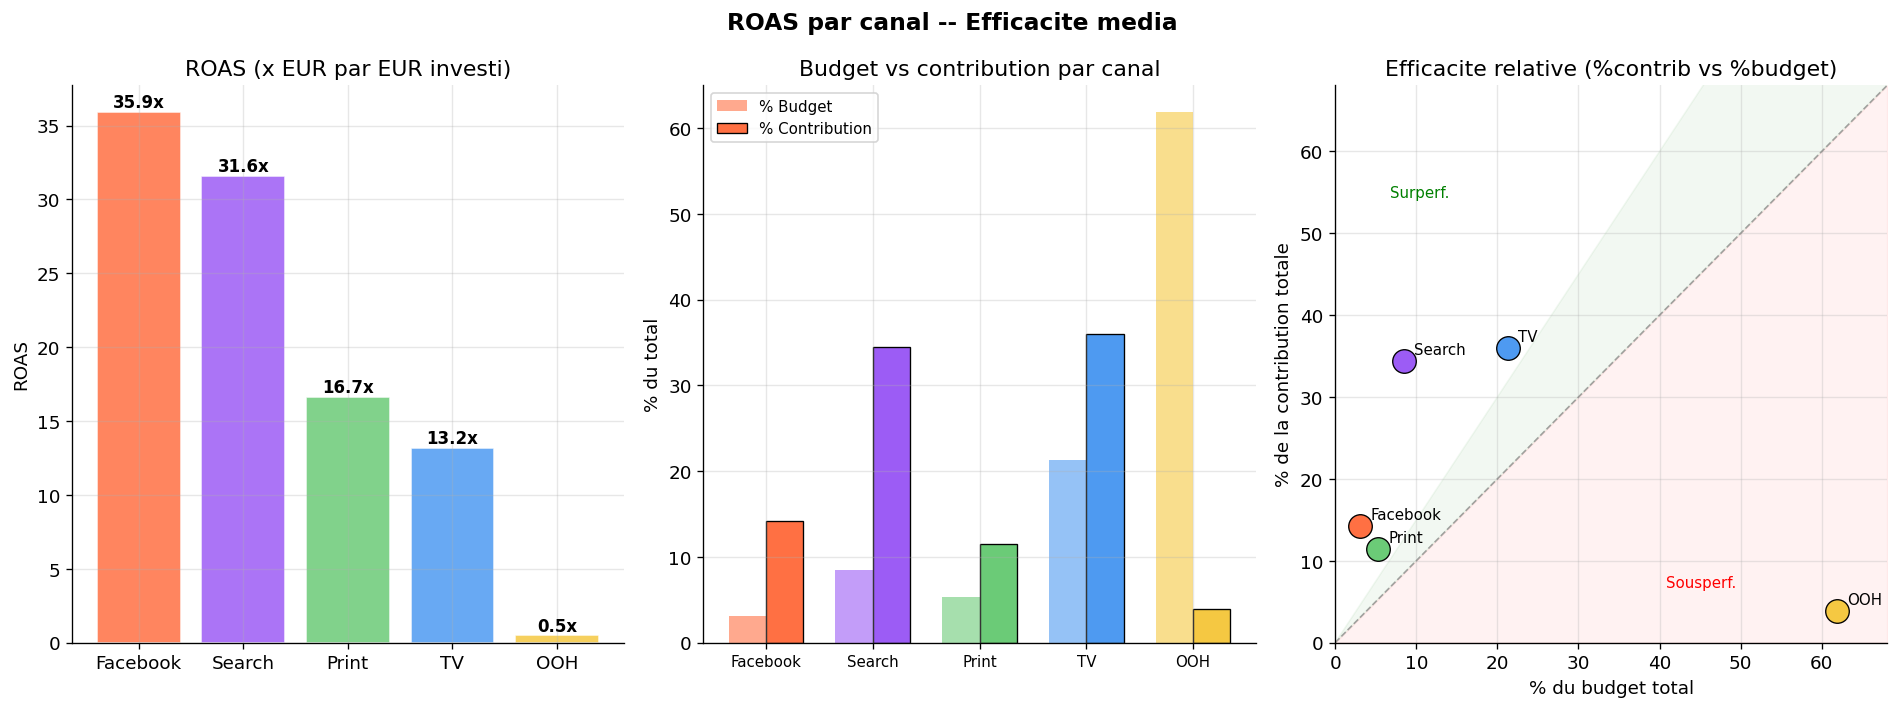

[OK] Figure sauvegardee


In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle("ROAS par canal -- Efficacite media", fontsize=14, fontweight="bold")

labels_r = roas_df["canal"].tolist()
colors_r = [MEDIA_COLORS[mc] for mc in media_present
            if MEDIA_LABELS[mc] in labels_r]
# Reordonner les couleurs selon roas_df
color_map = {MEDIA_LABELS[mc]: MEDIA_COLORS[mc] for mc in media_present}
colors_r  = [color_map[l] for l in labels_r]

# ROAS
ax = axes[0]
bars = ax.bar(labels_r, roas_df["roas"], color=colors_r, alpha=0.85, edgecolor="white")
ax.set_title("ROAS (x EUR par EUR investi)")
ax.set_ylabel("ROAS")
for bar, val in zip(bars, roas_df["roas"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"{val:.1f}x", ha="center", fontsize=10, fontweight="bold")

# Budget vs contribution
ax2 = axes[1]
x_pos = np.arange(len(labels_r))
width = 0.35
ax2.bar(x_pos - width/2, roas_df["spend_share"], width,
        label="% Budget", alpha=0.6, color=colors_r)
bars2 = ax2.bar(x_pos + width/2, roas_df["contrib_share"], width,
                label="% Contribution", alpha=1.0, color=colors_r, edgecolor="black", linewidth=0.8)
ax2.set_xticks(x_pos)
ax2.set_xticklabels(labels_r, fontsize=9)
ax2.set_ylabel("% du total")
ax2.set_title("Budget vs contribution par canal")
ax2.legend(fontsize=9)
ax2.axhline(y=0, color="black", linewidth=0.5)

# Scatter : spend vs contrib
ax3 = axes[2]
for _, row in roas_df.iterrows():
    col = color_map[row["canal"]]
    ax3.scatter(row["spend_share"], row["contrib_share"],
                s=200, color=col, zorder=5, edgecolors="black", linewidth=0.8)
    ax3.annotate(row["canal"], (row["spend_share"], row["contrib_share"]),
                 textcoords="offset points", xytext=(6, 4), fontsize=9)

max_val = max(roas_df["spend_share"].max(), roas_df["contrib_share"].max()) * 1.1
ax3.plot([0, max_val], [0, max_val], color="gray", linestyle="--", linewidth=1, alpha=0.7)
ax3.fill_between([0, max_val], [0, max_val], [0, max_val*1.5], alpha=0.05, color="green")
ax3.fill_between([0, max_val], [0, 0], [0, max_val], alpha=0.05, color="red")
ax3.annotate("Surperf.", xy=(max_val*0.1, max_val*0.8), fontsize=9, color="green")
ax3.annotate("Sousperf.", xy=(max_val*0.6, max_val*0.1), fontsize=9, color="red")
ax3.set_xlabel("% du budget total")
ax3.set_ylabel("% de la contribution totale")
ax3.set_title("Efficacite relative (%contrib vs %budget)")
ax3.set_xlim(0, max_val)
ax3.set_ylim(0, max_val)

plt.tight_layout()
plt.savefig("../outputs/figures/03_roas.png", bbox_inches="tight", dpi=150)
plt.show()
print("[OK] Figure sauvegardee")

## 6. Sauvegarde du modele

In [20]:
import pickle

# Sauvegarder le modele et les contributions
model_data = {
    "results":       results,
    "contributions": contributions,
    "roas_df":       roas_df,
    "trans_cols":    trans_cols,
    "media_present": media_present,
}

with open("../outputs/models/ols_model.pkl", "wb") as f:
    pickle.dump(model_data, f)

contributions.to_parquet("../data/processed/contributions.parquet", index=False)
roas_df.to_csv("../outputs/reports/roas_by_channel.csv", index=False)

print("[OK] Modele sauvegarde : ../outputs/models/ols_model.pkl")
print("[OK] Contributions     : ../data/processed/contributions.parquet")
print("[OK] ROAS rapport      : ../outputs/reports/roas_by_channel.csv")

[OK] Modele sauvegarde : ../outputs/models/ols_model.pkl
[OK] Contributions     : ../data/processed/contributions.parquet
[OK] ROAS rapport      : ../outputs/reports/roas_by_channel.csv


## 7. Synthese consultant

In [21]:
print("=" * 68)
print("  SYNTHESE -- MODELE OLS -- RobynMMM")
print("=" * 68)
print()
print(f"QUALITE DU MODELE")
print(f"  R²          = {results.rsquared:.3f}  ({results.rsquared*100:.1f}% de variance expliquee)")
print(f"  R² ajuste   = {results.rsquared_adj:.3f}")
print(f"  F-stat      = {results.fvalue:.1f}  (p={results.f_pvalue:.2e})")
dw = durbin_watson(results.resid)
print(f"  Durbin-Watson = {dw:.2f}  ({'OK' if 1.5<dw<2.5 else 'autocorrelation'})")
print()
print("CANAUX SIGNIFICATIFS")
for col, mc in zip(trans_cols, media_present):
    if col in results.params.index:
        pv = results.pvalues[col]
        sig = "*** significatif" if pv < 0.001 else "** significatif" if pv < 0.01 else "* significatif" if pv < 0.05 else "NON significatif"
        print(f"  {MEDIA_LABELS[mc]:<14} p={pv:.4f}  {sig}")
print()
print("ROAS (efficacite media)")
for _, row in roas_df.iterrows():
    eff = "(sur-perf)" if row["contrib_share"] > row["spend_share"] else "(sous-perf)"
    print(f"  {row['canal']:<14} ROAS={row['roas']:.1f}x  {eff}")
print()
print("PROCHAINE ETAPE --> Notebook 04 : Modele bayesien (PyMC)")
print("  - Distribution posterieure des coefficients")
print("  - Intervalles de credibilite sur les contributions")
print("  - Comparaison OLS vs Bayesien")
print("=" * 68)

  SYNTHESE -- MODELE OLS -- RobynMMM

QUALITE DU MODELE
  R²          = 0.835  (83.5% de variance expliquee)
  R² ajuste   = 0.820
  F-stat      = 56.4  (p=1.06e-64)
  Durbin-Watson = 2.04  (OK)

CANAUX SIGNIFICATIFS
  TV             p=0.0000  *** significatif
  OOH            p=0.4589  NON significatif
  Print          p=0.1837  NON significatif
  Facebook       p=0.0020  ** significatif
  Search         p=0.0007  *** significatif

ROAS (efficacite media)
  Facebook       ROAS=35.9x  (sur-perf)
  Search         ROAS=31.6x  (sur-perf)
  Print          ROAS=16.7x  (sur-perf)
  TV             ROAS=13.2x  (sur-perf)
  OOH            ROAS=0.5x  (sous-perf)

PROCHAINE ETAPE --> Notebook 04 : Modele bayesien (PyMC)
  - Distribution posterieure des coefficients
  - Intervalles de credibilite sur les contributions
  - Comparaison OLS vs Bayesien
